1. Imports

In [1]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

2. Configuration

In [2]:
DATABASE_PATH = "../data/database.db"

N_EPISODES = 1000
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.9
EPSILON = 0.1

3. Data Loading

In [3]:
def load_customer_segments(db_path):

    conn = sqlite3.connect(db_path)

    df = pd.read_sql_query(
        "SELECT * FROM customer_segments",
        conn
    )

    conn.close()

    return df


df = load_customer_segments(DATABASE_PATH)

df.head()

,customer_id,age,gender,location,transaction_count,avg_transaction_amount,total_spend,avg_session_duration,avg_pages_viewed,cluster,pca1,pca2
0,1,51,Female,US,10,184.142000,1841.42,22.6400,7.750000,0,2.529461,0.752117
1,2,65,Female,EU,5,171.098000,855.49,11.2200,11.000000,3,-0.525565,0.142979
2,3,22,Male,Asia,6,164.463333,986.78,18.6575,9.000000,3,-0.127387,0.602053
3,4,22,Male,Asia,3,232.743333,698.23,9.1600,9.333333,3,-0.814401,1.450552
4,5,25,Male,EU,8,168.895000,1351.16,7.4820,12.800000,2,1.117525,-0.746373


4. Environment Simulation

0 → No promotion
1 → Discount
2 → Loyalty reward

In [4]:
class MarketingEnvironment:

    def __init__(self, segments):

        self.segments = segments
        self.n_states = segments
        self.n_actions = 3

    def step(self, state, action):

        """
        Simulate customer response to a marketing action.
        Returns reward and next state.
        """

        # Probabilistic reward simulation
        if action == 1:  # discount
            reward = np.random.normal(5, 2)

        elif action == 2:  # loyalty reward
            reward = np.random.normal(4, 2)

        else:  # no promotion
            reward = np.random.normal(1, 1)

        next_state = state

        return reward, next_state

In [5]:
n_segments = df["cluster"].nunique()

env = MarketingEnvironment(n_segments)

5. Initializing Q-Tables

In [6]:
q_table = np.zeros((env.n_states, env.n_actions))

q_table

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

6. Training RL Agent

In [7]:
for episode in range(N_EPISODES):

    state = np.random.randint(env.n_states)

    if np.random.rand() < EPSILON:
        action = np.random.randint(env.n_actions)
    else:
        action = np.argmax(q_table[state])

    reward, next_state = env.step(state, action)

    old_value = q_table[state, action]

    next_max = np.max(q_table[next_state])

    new_value = old_value + LEARNING_RATE * (
        reward + DISCOUNT_FACTOR * next_max - old_value
    )

    q_table[state, action] = new_value

In [8]:
q_table

array([[12.50973118, 45.26543292, 19.78659937],
       [ 9.61827895,  7.06751965,  4.87920143],
       [14.2745117 , 43.12206523, 19.28473148],
       [ 9.19097486,  0.96684086,  3.62281964]])

7. Policy Visualization

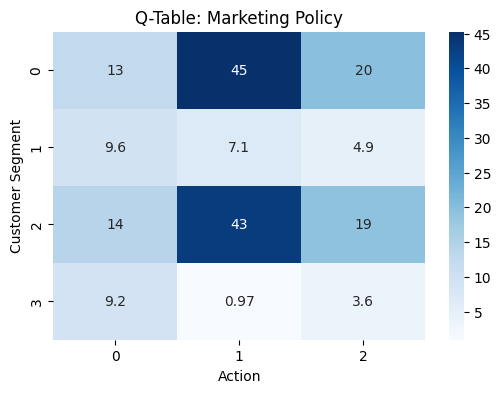

In [9]:
plt.figure(figsize=(6,4))

sns.heatmap(
    q_table,
    annot=True,
    cmap="Blues"
)

plt.title("Q-Table: Marketing Policy")
plt.xlabel("Action")
plt.ylabel("Customer Segment")

plt.show()

8. Business Insights

### Interpretation of the Learned Marketing Policy

The heatmap above represents the **Q-table learned by the reinforcement learning agent using Q-Learning**.
Each row corresponds to a **customer segment (state)** discovered earlier through clustering, and each column represents a **marketing action**.

**Actions**

* **0 — No Promotion**
* **1 — Discount**
* **2 — Loyalty Reward**

The values in each cell represent the **expected long-term reward** of applying a specific action to a given customer segment. Higher values indicate that the action is predicted to generate greater engagement or revenue.

---

### Segment-Level Insights

**Segment 0**

* Highest value: **Action 1 (Discount)** with a score around **45**
* Interpretation: These customers are likely **price-sensitive**, responding strongly to discounts.
* Business strategy: Offer targeted **discount campaigns** to increase conversions.

**Segment 1**

* Highest value: **Action 0 (No Promotion)** with a score around **9.6**
* Interpretation: These customers likely purchase without incentives and may already be engaged.
* Business strategy: **Avoid unnecessary promotions** to preserve profit margins.

**Segment 2**

* Highest value: **Action 1 (Discount)** with a score around **43**
* Interpretation: Similar to Segment 0, these customers react well to **price incentives**.
* Business strategy: Use **periodic discount offers** to stimulate purchases.

**Segment 3**

* Highest value: **Action 0 (No Promotion)** with a score around **9.2**
* Interpretation: Promotions do not significantly increase reward for this group.
* Business strategy: Focus on **organic engagement rather than promotional spending**.

---

### Key Takeaways

* The reinforcement learning agent discovered that **discounts are the most effective action for certain segments**, particularly segments **0 and 2**.
* For segments **1 and 3**, promotions provide limited benefit, suggesting that **marketing resources should not be wasted on incentives for these groups**.
* This demonstrates how reinforcement learning can be used to **optimize marketing strategies dynamically based on customer behavior**.

Overall, this experiment shows how reinforcement learning can move beyond prediction and help **automate decision-making policies** that maximize long-term business rewards.


In [10]:
best_actions = np.argmax(q_table, axis=1)

policy_df = pd.DataFrame({
    "segment": range(env.n_states),
    "best_action": best_actions
})

policy_df

,segment,best_action
0,0,1
1,1,0
2,2,1
3,3,0


In [11]:
action_map = {
    0: "No Promotion",
    1: "Discount",
    2: "Loyalty Reward"
}

policy_df["strategy"] = policy_df["best_action"].map(action_map)

policy_df

,segment,best_action,strategy
0,0,1,Discount
1,1,0,No Promotion
2,2,1,Discount
3,3,0,No Promotion


In [12]:
conn = sqlite3.connect(DATABASE_PATH)

policy_df.to_sql(
    "marketing_policy",
    conn,
    if_exists="replace",
    index=False
)

conn.close()